In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import numpy as np
import pandas as pd
sns.set()
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  *
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.applications import DenseNet121, VGG19, ResNet50

import PIL.Image
import matplotlib.pyplot as mpimg
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.preprocessing import image

from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

from sklearn.utils import shuffle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
from google.colab import drive
import os

#  掛載 Google Drive
drive.mount('/content/drive')

#  解壓縮檔案到 Colab 的暫存空間 (/content/chest_xray)
# 使用 -q 避免解壓時顯示幾千張照片的檔名，使用 -d 指定解壓資料夾
!unzip -q "/content/drive/MyDrive/1226/archive.zip" -d "/content/chest_xray"

# 讀取 CSV 檔案
# 通常 Kaggle 下載的 zip 解壓後，CSV 會在解壓資料夾的根目錄
csv_path = '/content/chest_xray/Chest_xray_Corona_Metadata.csv'

if os.path.exists(csv_path):
    train_df = pd.read_csv(csv_path)
    print("讀取成功！")
    print(f"Dataset Shape: {train_df.shape}")
else:
    print("找不到 CSV 檔案，請檢查解壓後的檔案結構。")
    # 如果找不到，可以用這行指令看看解壓出來到底有哪些檔案
    !ls -R /content/chest_xray

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
讀取成功！
Dataset Shape: (5910, 6)


In [4]:
train_df.head(5)

,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5910 entries, 0 to 5909
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              5910 non-null   int64 
 1   X_ray_image_name        5910 non-null   object
 2   Label                   5910 non-null   object
 3   Dataset_type            5910 non-null   object
 4   Label_2_Virus_category  69 non-null     object
 5   Label_1_Virus_category  4334 non-null   object
dtypes: int64(1), object(5)
memory usage: 277.2+ KB


<Axes: >

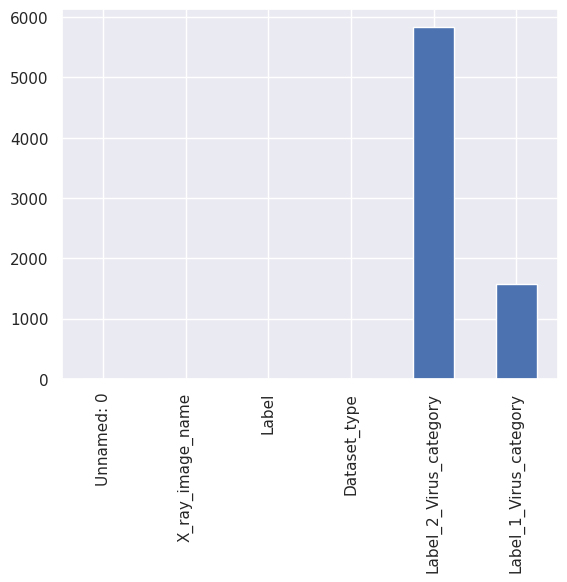

In [6]:
missing_vals = train_df.isnull().sum()
missing_vals.plot(kind = 'bar')

In [7]:
train_df.dropna(how = 'all')
train_df.isnull().sum()

,0
Unnamed: 0,0
X_ray_image_name,0
Label,0
Dataset_type,0
Label_2_Virus_category,5841
Label_1_Virus_category,1576


In [8]:
train_df.fillna('unknown', inplace=True)
train_df.isnull().sum()

,0
Unnamed: 0,0
X_ray_image_name,0
Label,0
Dataset_type,0
Label_2_Virus_category,0
Label_1_Virus_category,0


In [9]:
train_data = train_df[train_df['Dataset_type'] == 'TRAIN']
test_data = train_df[train_df['Dataset_type'] == 'TEST']
assert train_data.shape[0] + test_data.shape[0] == train_df.shape[0]
print(f"Shape of train data : {train_data.shape}")
print(f"Shape of test data : {test_data.shape}")
test_data.sample(10)

Shape of train data : (5286, 6)
Shape of test data : (624, 6)


,Unnamed: 0,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
5881,5904,person1665_virus_2878.jpeg,Pnemonia,TEST,unknown,Virus
5373,5396,IM-0025-0001.jpeg,Normal,TEST,unknown,unknown
5507,5530,NORMAL2-IM-0351-0001.jpeg,Normal,TEST,unknown,unknown
5599,5622,person138_bacteria_658.jpeg,Pnemonia,TEST,unknown,bacteria
5365,5388,IM-0033-0001.jpeg,Normal,TEST,unknown,unknown
5396,5419,NORMAL2-IM-0311-0001.jpeg,Normal,TEST,unknown,unknown
5816,5839,person41_virus_88.jpeg,Pnemonia,TEST,unknown,Virus
5307,5330,NORMAL2-IM-0058-0001.jpeg,Normal,TEST,unknown,unknown
5781,5804,person76_virus_138.jpeg,Pnemonia,TEST,unknown,Virus
5448,5471,NORMAL2-IM-0210-0001.jpeg,Normal,TEST,unknown,unknown


In [10]:
print((train_df['Label_1_Virus_category']).value_counts())
print('--------------------------')
print((train_df['Label_2_Virus_category']).value_counts())

Label_1_Virus_category
bacteria          2777
unknown           1576
Virus             1555
Stress-Smoking       2
Name: count, dtype: int64
--------------------------
Label_2_Virus_category
unknown          5841
COVID-19           58
Streptococcus       5
SARS                4
ARDS                2
Name: count, dtype: int64


In [12]:
test_img_dir = '/content/chest_xray/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/test'
train_img_dir = '/content/chest_xray/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train'

sample_train_images = list(os.walk(train_img_dir))[0][2][:8]
sample_train_images = list(map(lambda x: os.path.join(train_img_dir, x), sample_train_images))

sample_test_images = list(os.walk(test_img_dir))[0][2][:8]
sample_test_images = list(map(lambda x: os.path.join(test_img_dir, x), sample_test_images))

print("第一張訓練片路徑:", sample_train_images[0])
print("訓練片數量:", len(sample_train_images))

第一張訓練片路徑: /content/chest_xray/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/NORMAL2-IM-0520-0001.jpeg
訓練片數量: 8


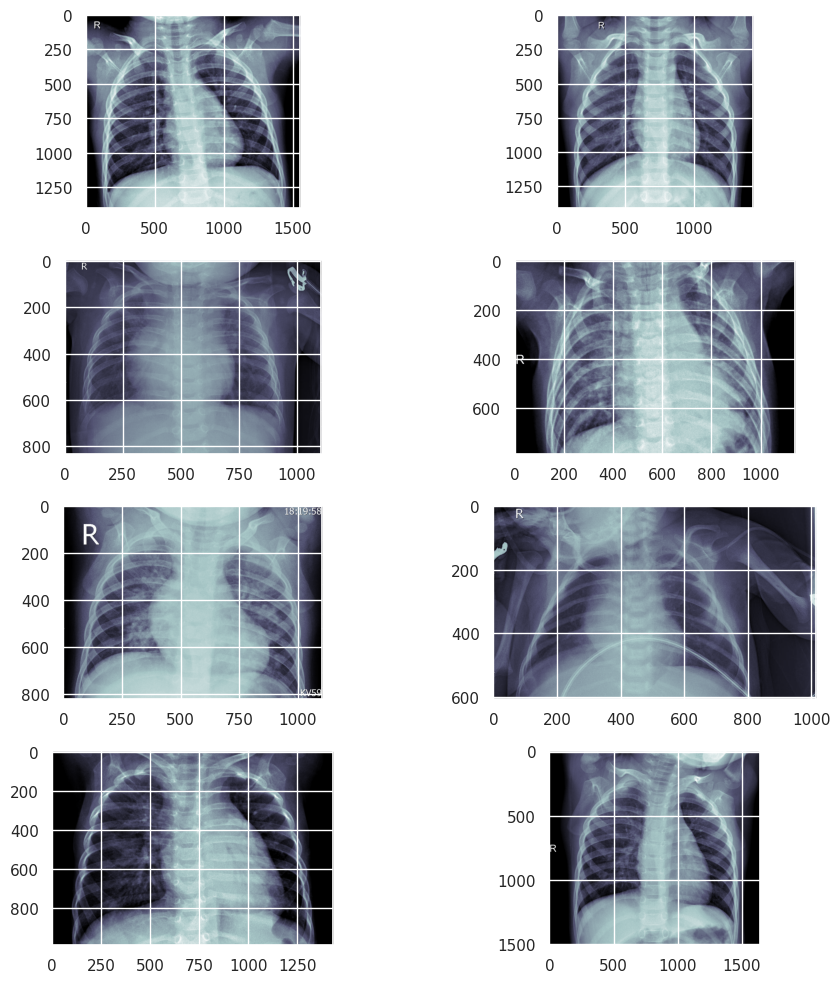

In [13]:
plt.figure(figsize = (10,10))
for iterator, filename in enumerate(sample_train_images):
    image = PIL.Image.open(filename)
    plt.subplot(4,2,iterator+1)
    plt.imshow(image, cmap=plt.cm.bone)

plt.tight_layout()

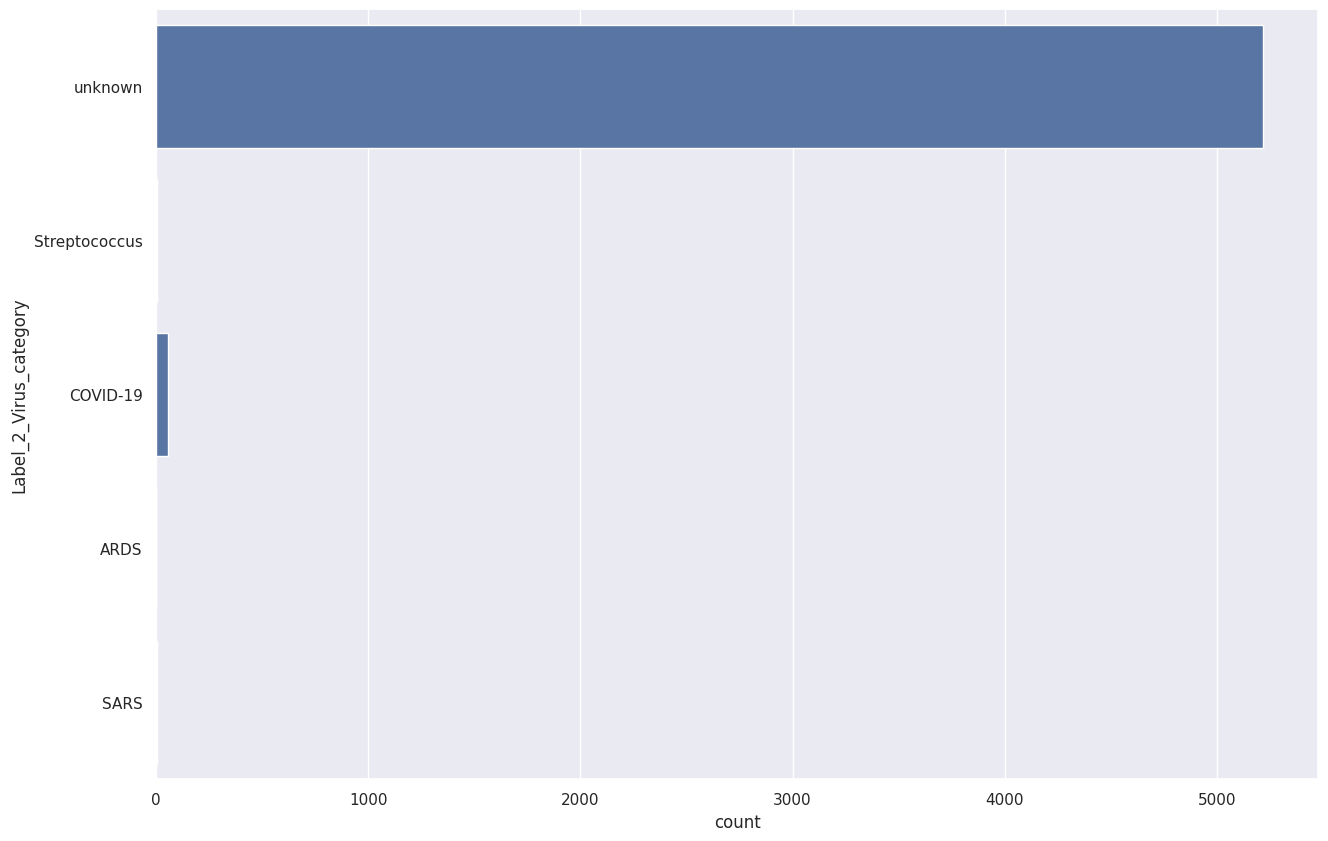

In [14]:
plt.figure(figsize=(15,10))
sns.countplot(train_data['Label_2_Virus_category']);

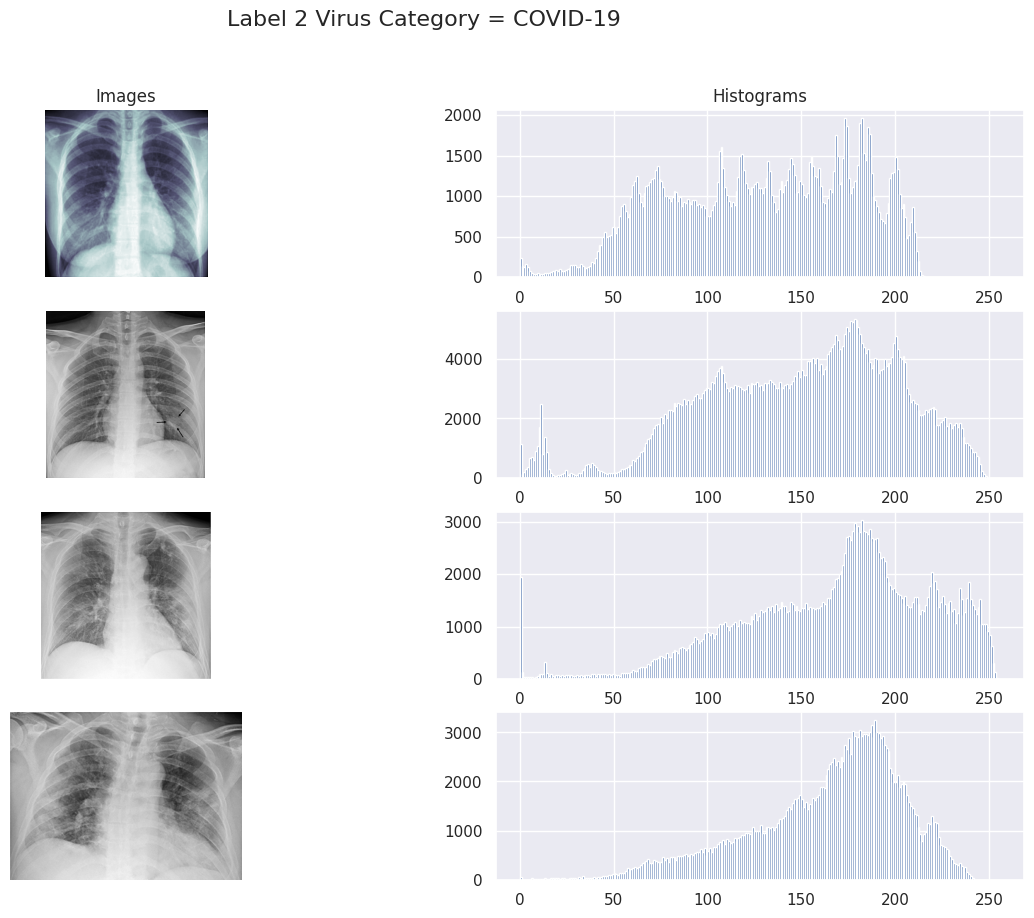

In [15]:
fig, ax = plt.subplots(4, 2, figsize=(15, 10))


covid_path = train_data[train_data['Label_2_Virus_category']=='COVID-19']['X_ray_image_name'].values

sample_covid_path = covid_path[:4]
sample_covid_path = list(map(lambda x: os.path.join(train_img_dir, x), sample_covid_path))

for row, file in enumerate(sample_covid_path):
    image = plt.imread(file)
    ax[row, 0].imshow(image, cmap=plt.cm.bone)
    ax[row, 1].hist(image.ravel(), 256, [0,256])
    ax[row, 0].axis('off')
    if row == 0:
        ax[row, 0].set_title('Images')
        ax[row, 1].set_title('Histograms')
fig.suptitle('Label 2 Virus Category = COVID-19', size=16)
plt.show()

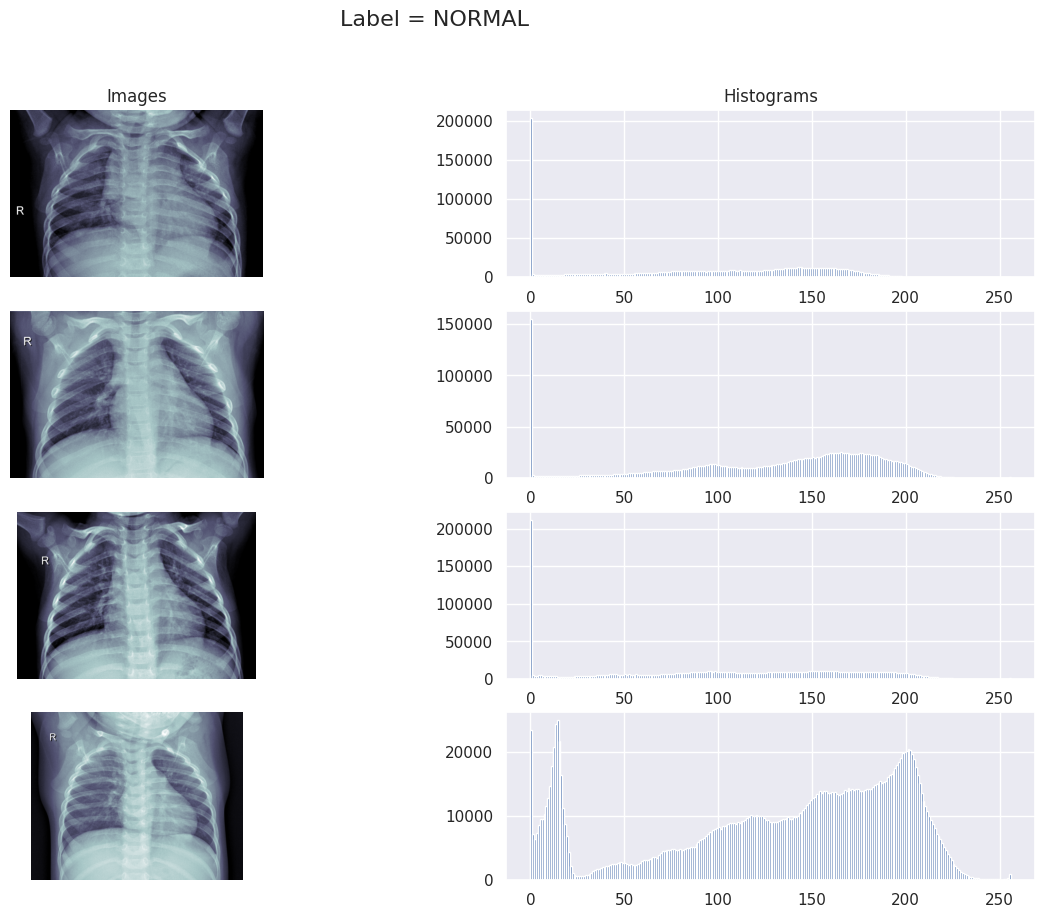

In [16]:
fig, ax = plt.subplots(4, 2, figsize=(15, 10))


normal_path = train_data[train_data['Label']=='Normal']['X_ray_image_name'].values

sample_normal_path = normal_path[:4]
sample_normal_path = list(map(lambda x: os.path.join(train_img_dir, x), sample_normal_path))

for row, file in enumerate(sample_normal_path):
    image = plt.imread(file)
    ax[row, 0].imshow(image, cmap=plt.cm.bone)
    ax[row, 1].hist(image.ravel(), 256, [0,256])
    ax[row, 0].axis('off')
    if row == 0:
        ax[row, 0].set_title('Images')
        ax[row, 1].set_title('Histograms')
fig.suptitle('Label = NORMAL', size=16)
plt.show()

In [17]:
final_train_data = train_data[(train_data['Label'] == 'Normal') |
                              ((train_data['Label'] == 'Pnemonia') &
                               (train_data['Label_2_Virus_category'] == 'COVID-19'))]

In [18]:
final_train_data['class'] = final_train_data.Label.apply(lambda x: 'negative' if x=='Normal' else 'positive')
test_data['class'] = test_data.Label.apply(lambda x: 'negative' if x=='Normal' else 'positive')

final_train_data['target'] = final_train_data.Label.apply(lambda x: 0 if x=='Normal' else 1)
test_data['target'] = test_data.Label.apply(lambda x: 0 if x=='Normal' else 1)

In [19]:
final_train_data = final_train_data[['X_ray_image_name', 'class', 'target', 'Label_2_Virus_category']]
final_test_data = test_data[['X_ray_image_name', 'class', 'target']]

In [20]:
test_data['Label'].value_counts()

,count
Label,
Pnemonia,390
Normal,234


In [25]:
datagen =  ImageDataGenerator(
  shear_range=0.2,
  zoom_range=0.2,
)

def read_img(filename, size, path):
    img = image.load_img(os.path.join(path, filename), target_size=size)
    #convert image to array
    img = image.img_to_array(img) / 255
    return img

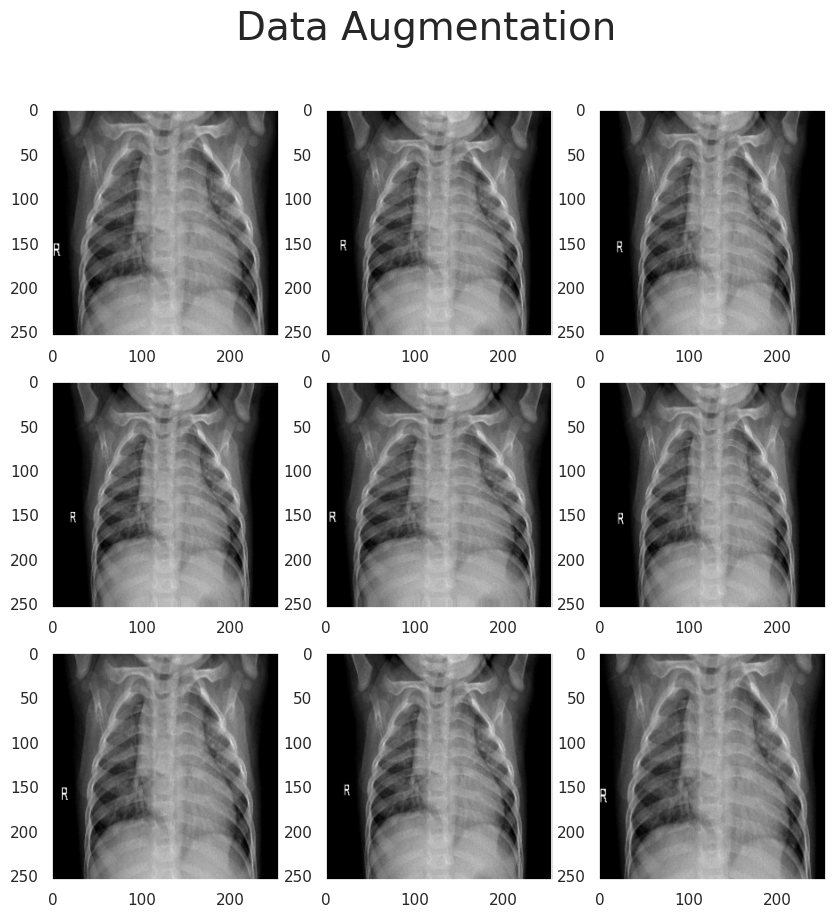

In [28]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


datagen = ImageDataGenerator(
    shear_range=0.2,
    zoom_range=0.2,
)

def read_img(filename, size, path):
    full_path = os.path.join(path, filename)
    img = image.load_img(full_path, target_size=size)
    img = image.img_to_array(img) / 255
    return img

samp_img = read_img(final_train_data['X_ray_image_name'][0],
                    (255, 255),
                    train_img_dir)

plt.figure(figsize=(10,10))
plt.suptitle('Data Augmentation', fontsize=28)

i = 0
for batch in datagen.flow(tf.expand_dims(samp_img, 0), batch_size=1):
    plt.subplot(3, 3, i+1)
    plt.grid(False)
    plt.imshow(batch[0])

    if i == 8:
        break
    i += 1

plt.show()

In [29]:
from tqdm.notebook import tqdm
import numpy as np


corona_df = final_train_data[final_train_data['Label_2_Virus_category'] == 'COVID-19']
with_corona_augmented = []


def augment(name):

    img = read_img(name, (255, 255), train_img_dir)

    i = 0
    for batch in datagen.flow(tf.expand_dims(img, 0), batch_size=1):

        augmented_img = batch[0]
        with_corona_augmented.append(augmented_img)

        if i == 20:
            break
        i += 1

print(f"開始增強 COVID-19 圖片，預計處理 {len(corona_df)} 張原圖...")
for img_name in tqdm(corona_df['X_ray_image_name']):
    augment(img_name)

print(f"增強完成！總共產生了 {len(with_corona_augmented)} 張圖片。")

開始增強 COVID-19 圖片，預計處理 58 張原圖...


  0%|          | 0/58 [00:00<?, ?it/s]

增強完成！總共產生了 1218 張圖片。


In [30]:
from tqdm.notebook import tqdm
import numpy as np


train_arrays = []
print("正在讀取訓練集圖片...")
for img_name in tqdm(final_train_data['X_ray_image_name']):

    img_array = read_img(img_name, (255, 255), train_img_dir)
    train_arrays.append(img_array)

test_arrays = []
print("正在讀取測試集圖片...")
for img_name in tqdm(final_test_data['X_ray_image_name']):

    img_array = read_img(img_name, (255, 255), test_img_dir)
    test_arrays.append(img_array)


print(f"訓練集讀取完成，共 {len(train_arrays)} 張")
print(f"測試集讀取完成，共 {len(test_arrays)} 張")

正在讀取訓練集圖片...


  0%|          | 0/1400 [00:00<?, ?it/s]

正在讀取測試集圖片...


  0%|          | 0/624 [00:00<?, ?it/s]

訓練集讀取完成，共 1400 張
測試集讀取完成，共 624 張


In [31]:
y_train = np.concatenate((np.int64(final_train_data['target'].values), np.ones(len(with_corona_augmented), dtype=np.int64)))

In [32]:
train_tensors = tf.convert_to_tensor(np.concatenate((np.array(train_arrays), np.array(with_corona_augmented))))
test_tensors  = tf.convert_to_tensor(np.array(test_arrays))
y_train_tensor = tf.convert_to_tensor(y_train)
y_test_tensor = tf.convert_to_tensor(final_test_data['target'].values)

train_dataset = tf.data.Dataset.from_tensor_slices((train_tensors, y_train_tensor))
test_dataset = tf.data.Dataset.from_tensor_slices((test_tensors, y_test_tensor))

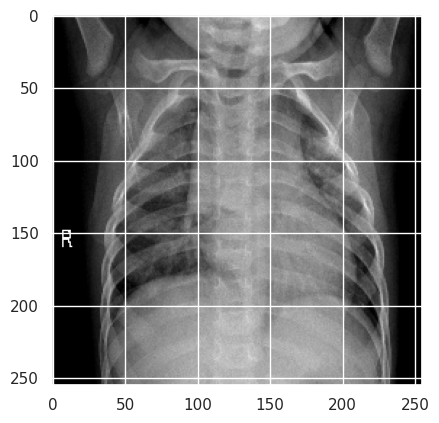

In [33]:
for i,l in train_dataset.take(1):
    plt.imshow(i);

In [34]:
BATCH_SIZE = 16
BUFFER = 1000

train_batches = train_dataset.shuffle(BUFFER).batch(BATCH_SIZE)
test_batches = test_dataset.batch(BATCH_SIZE)

for i,l in train_batches.take(1):
    print('Train Shape per Batch: ',i.shape);
for i,l in test_batches.take(1):
    print('Test Shape per Batch: ',i.shape);

Train Shape per Batch:  (16, 255, 255, 3)
Test Shape per Batch:  (16, 255, 255, 3)


In [35]:
INPUT_SHAPE = (255,255,3)

base_model = tf.keras.applications.ResNet50(input_shape= INPUT_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

# We set it to False because we don't want to mess with the pretrained weights of the model.
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [37]:
for i, l in train_batches.take(1):
    pass
print(base_model(i).shape)

(16, 8, 8, 2048)


In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

model = Sequential()
model.add(base_model)

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation='sigmoid'))


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [40]:
callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)


model.compile(optimizer='adam',
              loss = 'binary_crossentropy',
              metrics=['accuracy'])

In [41]:
model.fit(train_batches, epochs=10, validation_data=test_batches, callbacks=[callbacks])

Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 36s 123ms/step - accuracy: 0.8305 - loss: 0.4355 - val_accuracy: 0.6250 - val_loss: 0.6632
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.6012 - loss: 0.6308 - val_accuracy: 0.6250 - val_loss: 0.6809
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.2476 - loss: 0.7190 - val_accuracy: 0.6250 - val_loss: 0.6828


In [45]:
import numpy as np

predictions = model.predict(np.array(test_arrays))

pred = (predictions > 0.5).astype("int32")


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step


In [46]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_data['target'], pred.flatten()))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       234
           1       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



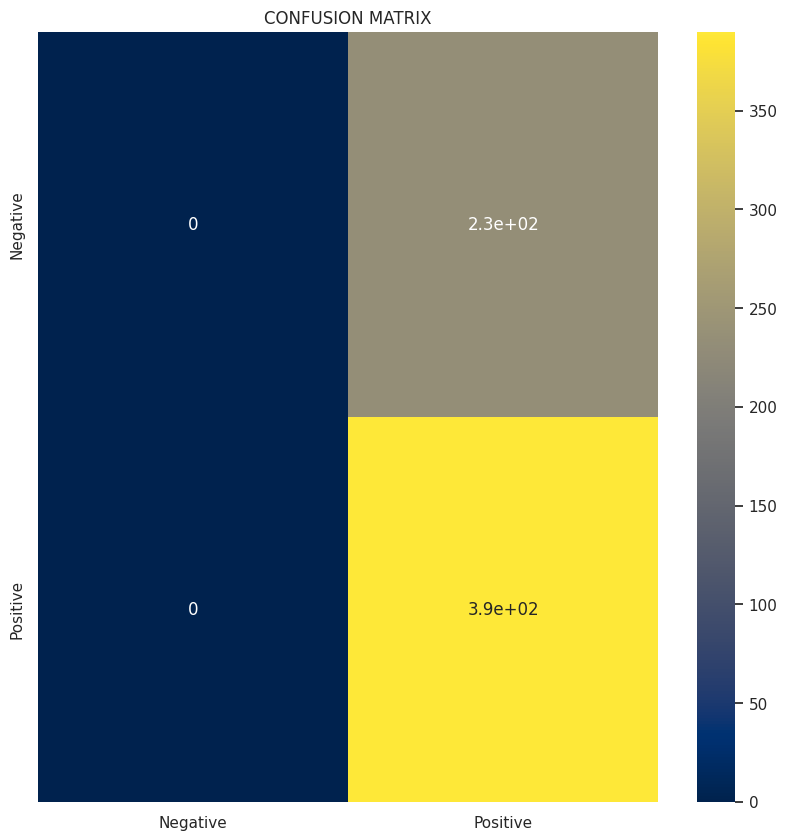

In [47]:
con_mat = confusion_matrix(test_data['target'], pred.flatten())
plt.figure(figsize = (10,10))
plt.title('CONFUSION MATRIX')
sns.heatmap(con_mat, cmap='cividis',
            yticklabels=['Negative', 'Positive'],
            xticklabels=['Negative', 'Positive'],
            annot=True);